Importing Necessary Libaries 

In [2]:
import os 
import math 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 
import warnings

In [3]:
path = os.path.join('Data_Sets','Crypto_CurrencyData.csv')
df_raw=pd.read_csv(path)

Initial Inspection

In [4]:
df_raw.head()

,Rank,Coin Name,Symbol,Price,1h,24h,7d,30d,24h Volume,Circulating Supply,Total Supply,Market Cap
0,1,Bitcoin,BTC,"36,456.94",0.40%,-1.70%,1.00%,18.40%,"$22,801,222,945.00","19,549,806",21 Million,"$712,726,163,003.00"
1,2,Ethereum,ETH,"2,027.60",0.50%,1.40%,1.00%,20.70%,"$26,845,710,464.00","120,249,015",120 Million,"$243,488,187,281.00"
2,3,Tether,USDT,1,0.10%,-0.30%,-0.10%,-0.10%,"$47,122,466,339.00","88,308,652,879",88.3 Billion,"$88,027,617,310.00"
3,4,BNB,BNB,231.63,-0.10%,-12.60%,-8.00%,5.40%,"$3,715,265,116.00","153,856,150",154 Million,"$35,716,332,862.00"
4,5,XRP,XRP,0.59,0.10%,-1.90%,-6.90%,12.10%,"$1,339,890,506.00","53,718,306,475",100 Billion,"$31,863,926,051.00"


In [5]:
df_raw.tail()

,Rank,Coin Name,Symbol,Price,1h,24h,7d,30d,24h Volume,Circulating Supply,Total Supply,Market Cap
995,996,Ethereum Meta,ETHM,$-,-0.10%,4.10%,2.70%,23.30%,"$4,731.00","1,000,991,099,000,000,000",1000 Quadrillion,"$10,759,447.00"
996,997,Swarm Markets,SMT,0.18,-0.10%,14.80%,27.00%,142.70%,"$190,773.00","60,914,132",245 Million,"$10,751,558.00"
997,998,Real Smurf Cat,Ð¨ÐÐ™Ð›Ð£Ð¨ÐÐ™,$-,-16.90%,-16.70%,-6.70%,97.30%,"$826,561.00","100,000,000,000",100 Billion,"$10,743,462.00"
998,999,Genopets,GENE,0.33,0.80%,0.90%,-12.20%,129.60%,"$62,625.00","32,181,006",100 Million,"$10,699,886.00"
999,1000,APF coin,APFC,0.19,-0.20%,-0.30%,6.80%,-0.90%,"$322,091.00","56,821,262",250 Million,"$10,675,320.00"


In [6]:
df_raw.shape

(1000, 12)

In [7]:
df_raw.describe()

,Rank
count,1000.000000
mean,500.500000
std,288.819436
min,1.000000
25%,250.750000
50%,500.500000
75%,750.250000
max,1000.000000


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Rank                1000 non-null   int64
 1   Coin Name           1000 non-null   str  
 2   Symbol              1000 non-null   str  
 3    Price              1000 non-null   str  
 4   1h                  997 non-null    str  
 5   24h                 1000 non-null   str  
 6   7d                  999 non-null    str  
 7   30d                 993 non-null    str  
 8    24h Volume         1000 non-null   str  
 9   Circulating Supply  1000 non-null   str  
 10  Total Supply        1000 non-null   str  
 11   Market Cap         1000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 93.9 KB


# Memory Allocated by this File 

In [9]:
Mem_Alloc=f"{(df_raw.memory_usage(deep=True).sum()/(1024*1024)):.2f}"
print("The Memory Consumed by this CSV file is ",Mem_Alloc,"MB")

The Memory Consumed by this CSV file is  0.61 MB


## Data Cleaning :

### Fixing Column Names

In [10]:
df= df_raw.copy()  # working on copy so raw data stay preserved

In [11]:
df.columns = df.columns.str.strip()
# Stripping leading whitespace from Column headers

In [12]:
df.rename(columns={
    'Rank' : 'rank',
    'Coin Name' : 'name',
    'Symbol' : 'symbol',
    'Price' : 'price',
    '1h' : 'change_1h',
    '24h' : 'change_24h' , 
    '7d' : 'change_7d' , 
    '30d' : 'change_30d' ,
    '24h Volume' : 'volume_24h',
    'Circulating Supply' : 'circ_supply',
    'Total Supply' : 'total_supplly',
    'Market Cap' : 'market_cap'
},inplace=True)
print(df.columns.tolist())

['rank', 'name', 'symbol', 'price', 'change_1h', 'change_24h', 'change_7d', 'change_30d', 'volume_24h', 'circ_supply', 'total_supplly', 'market_cap']


### Clean Numeric Columns

In [13]:
#def clean_money(series):
#    return(
#        series.astype(str)
#              .str.replace(r'[\$,\s]','',regex=True)
#              .str.replace(r'-$','',regex=True)
#              .replace({'':np.nan,'-':np.nan,'nan':np.nan})
#              .pipe(pd.to_numeric,errors='coerce')
#    )

def clean_money(series):
    return (
        series.astype(str)
              .str.replace(r'[\$,\s]', '', regex=True)  # \s lowercase
              .replace({'': np.nan, '-': np.nan, 'nan': np.nan})
              .pipe(pd.to_numeric, errors='coerce')
    )

def clean_percent(series):
    return(
        series.astype(str)
                .str.strip()
                .str.replace("%",'',regex=True)
                .replace({'':np.nan,'-':np.nan,'nan':np.nan})
                .pipe(pd.to_numeric,errors='coerce')
    )

df['price'] =clean_money(df['price'])
df['volume_24h']=clean_money(df['volume_24h'])
df['market_cap']=clean_money(df['market_cap'])
df['circ_supply'] = (
    df['circ_supply'].astype(str)
                    .str.replace(r'[,\s]','',regex=True)
                    .pipe(pd.to_numeric,errors='coerce')
)

#cleaning percentage change columns 
for col in ['change_1h','change_24h','change_7d','change_30d']:
    df[col]=clean_percent(df[col])

#strip whitespace from text columns
df['name'] = df['name'].str.strip()
df['symbol'] = df['symbol'].str.strip()

print(df.dtypes)
df.head()

rank               int64
name                 str
symbol               str
price            float64
change_1h        float64
change_24h       float64
change_7d        float64
change_30d       float64
volume_24h       float64
circ_supply        int64
total_supplly        str
market_cap       float64
dtype: object


,rank,name,symbol,price,change_1h,change_24h,change_7d,change_30d,volume_24h,circ_supply,total_supplly,market_cap
0,1,Bitcoin,BTC,36456.94,0.4,-1.7,1.0,18.4,2.280122e+10,19549806,21 Million,7.127262e+11
1,2,Ethereum,ETH,2027.60,0.5,1.4,1.0,20.7,2.684571e+10,120249015,120 Million,2.434882e+11
2,3,Tether,USDT,1.00,0.1,-0.3,-0.1,-0.1,4.712247e+10,88308652879,88.3 Billion,8.802762e+10
3,4,BNB,BNB,231.63,-0.1,-12.6,-8.0,5.4,3.715265e+09,153856150,154 Million,3.571633e+10
4,5,XRP,XRP,0.59,0.1,-1.9,-6.9,12.1,1.339891e+09,53718306475,100 Billion,3.186393e+10


In [14]:
df.head()

,rank,name,symbol,price,change_1h,change_24h,change_7d,change_30d,volume_24h,circ_supply,total_supplly,market_cap
0,1,Bitcoin,BTC,36456.94,0.4,-1.7,1.0,18.4,2.280122e+10,19549806,21 Million,7.127262e+11
1,2,Ethereum,ETH,2027.60,0.5,1.4,1.0,20.7,2.684571e+10,120249015,120 Million,2.434882e+11
2,3,Tether,USDT,1.00,0.1,-0.3,-0.1,-0.1,4.712247e+10,88308652879,88.3 Billion,8.802762e+10
3,4,BNB,BNB,231.63,-0.1,-12.6,-8.0,5.4,3.715265e+09,153856150,154 Million,3.571633e+10
4,5,XRP,XRP,0.59,0.1,-1.9,-6.9,12.1,1.339891e+09,53718306475,100 Billion,3.186393e+10


### Handling Missing Values 

In [15]:
missing = df.isnull().sum()
missing_pct=(missing/len(df)*100).round(2)
missing_df=pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct})
print(missing_df[missing_df['Missing Count']>0].to_string())
df.head()

            Missing Count  Missing %
price                 115       11.5
change_1h              12        1.2
change_24h              9        0.9
change_7d              10        1.0
change_30d             16        1.6
volume_24h             10        1.0


,rank,name,symbol,price,change_1h,change_24h,change_7d,change_30d,volume_24h,circ_supply,total_supplly,market_cap
0,1,Bitcoin,BTC,36456.94,0.4,-1.7,1.0,18.4,2.280122e+10,19549806,21 Million,7.127262e+11
1,2,Ethereum,ETH,2027.60,0.5,1.4,1.0,20.7,2.684571e+10,120249015,120 Million,2.434882e+11
2,3,Tether,USDT,1.00,0.1,-0.3,-0.1,-0.1,4.712247e+10,88308652879,88.3 Billion,8.802762e+10
3,4,BNB,BNB,231.63,-0.1,-12.6,-8.0,5.4,3.715265e+09,153856150,154 Million,3.571633e+10
4,5,XRP,XRP,0.59,0.1,-1.9,-6.9,12.1,1.339891e+09,53718306475,100 Billion,3.186393e+10


#### Filling numeric NaN with 0 for supply/volume ; 
### Keeping Price/market_cap NaN

In [16]:
df['circ_supply'].fillna(0,inplace=True)
df['volume_24h'].fillna(0,inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13332\3937425864.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['circ_supply'].fillna(0,inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13332\3937425864.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

0      2.280122e+10
1      2.684571e+10
2      4.712247e+10
3      3.715265e+09
4      1.339891e+09
           ...     
995    4.731000e+03
996    1.907730e+05
997    8.265610e+05
998    6.262500e+04
999    3.220910e+05
Name: volume_24h, Length: 1000, dtype: float64

#### Fill percentage changes with 0 

In [17]:
for col in ['change_1h','change_24h','change_7d','change_30d']:
    df[col].fillna(0,inplace = True)

    

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13332\1989659693.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(0,inplace = True)


In [18]:
#### Droping rows with no price and Market_Cap 
before=len(df)
df.dropna(subset=['price','market_cap'],how='all',inplace=True)
df.reset_index(drop=True,inplace=True)
after=len(df)
print(f'\nInitial Rows = {before} \nFinal Rows = {after} \nLines Dropped = {before-after}')


Initial Rows = 1000 
Final Rows = 1000 
Lines Dropped = 0


### Removing Duplicate & Validate

#### Checking for duplicate coin name or symbols

In [19]:
dup_names=df.duplicated(subset=['name'],keep=False).sum()
dup_symbols=df.duplicated(subset=['symbol'],keep=False).sum()
print(f'Duplicate Names: {dup_names}')
print(f'Duplicate Symbols: {dup_symbols}')

Duplicate Names: 0
Duplicate Symbols: 23


#### Keeping first occurance of any duplicates

In [20]:
df.drop_duplicates(subset=['name'],keep='first',inplace=True)
df.reset_index(drop=True,inplace=True)

#### Add a derived column ; volume-to-mamrket-cap ratio

In [21]:
df['vol_to_cap']=np.where(
    df['market_cap']>0,
    (df['volume_24h']/df['market_cap']*100).round(4),np.nan
    )

In [22]:
print(f'\nFinal Cleaned dataset: {df.shape[0]} rows {df.shape[1]}columns')
print('Sample of cleaned data:')
df[['rank','name','symbol','price','change_24h','volume_24h','market_cap']].head(10)


Final Cleaned dataset: 1000 rows 13columns
Sample of cleaned data:


,rank,name,symbol,price,change_24h,volume_24h,market_cap
0,1,Bitcoin,BTC,36456.94,-1.7,2.280122e+10,7.127262e+11
1,2,Ethereum,ETH,2027.60,1.4,2.684571e+10,2.434882e+11
2,3,Tether,USDT,1.00,-0.3,4.712247e+10,8.802762e+10
3,4,BNB,BNB,231.63,-12.6,3.715265e+09,3.571633e+10
4,5,XRP,XRP,0.59,-1.9,1.339891e+09,3.186393e+10
5,6,USDC,USDC,1.00,-0.4,1.645824e+10,2.412008e+10
6,7,Solana,SOL,54.97,-0.6,2.374980e+09,2.325809e+10
7,8,Lido Staked Ether,STETH,2023.81,1.5,1.762554e+07,1.843532e+10
8,9,Cardano,ADA,0.37,-1.6,3.732770e+08,1.290396e+10
9,10,Dogecoin,DOGE,0.07,-2.3,9.572257e+08,1.053291e+10


### Overall DataSet Summary Statistics

In [23]:
numeric_cols = ['price', 'change_1h', 'change_24h', 'change_7d', 'change_30d',
                'volume_24h', 'market_cap', 'circ_supply']

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['skewness'] = df[numeric_cols].skew()

print('📈 Descriptive Statistics of Clean Dataset:')
summary.round(2)

📈 Descriptive Statistics of Clean Dataset:


,count,mean,std,min,25%,50%,75%,max,median,skewness
price,885.0,4.036200e+02,3.492120e+03,0.01,0.07,3.300000e-01,1.600000e+00,3.763421e+04,3.300000e-01,10.08
change_1h,988.0,2.200000e-01,1.830000e+00,-16.90,-0.20,1.000000e-01,6.000000e-01,2.330000e+01,1.000000e-01,1.25
change_24h,991.0,-3.400000e-01,7.920000e+00,-36.30,-4.00,-1.500000e+00,1.200000e+00,7.740000e+01,-1.500000e+00,3.68
change_7d,990.0,2.830000e+00,3.415000e+01,-63.90,-9.20,-3.300000e+00,2.600000e+00,5.060000e+02,-3.300000e+00,7.65
change_30d,984.0,5.724000e+01,1.769000e+02,-70.80,5.57,2.125000e+01,4.962000e+01,3.364300e+03,2.125000e+01,10.76
volume_24h,990.0,1.501137e+08,1.950139e+09,0.47,295374.00,1.540532e+06,9.544262e+06,4.712247e+10,1.540532e+06,18.96
market_cap,1000.0,1.437977e+09,2.404638e+10,10675320.00,19755869.50,4.490749e+07,1.295327e+08,7.127262e+11,4.490749e+07,27.04
circ_supply,1000.0,1.481022e+15,3.266741e+16,0.00,44046343.25,2.687451e+08,1.425415e+09,1.000991e+18,2.687451e+08,29.02


### Interaction With Project

In [24]:
def format_large_number(num):
    """Returns a human-readable string for large numbers."""
    if pd.isna(num) or num == 0:
        return 'N/A'
    if abs(num) >= 1e12:
        return f'${num/1e12:.3f} Trillion'
    elif abs(num) >= 1e9:
        return f'${num/1e9:.3f} Billion'
    elif abs(num) >= 1e6:
        return f'${num/1e6:.3f} Million'
    else:
        return f'${num:,.2f}'

def format_supply(num):
    """Returns a human-readable supply string (no $ prefix)."""
    if pd.isna(num) or num == 0:
        return 'N/A'
    if abs(num) >= 1e12:
        return f'{num/1e12:.3f} Trillion'
    elif abs(num) >= 1e9:
        return f'{num/1e9:.3f} Billion'
    elif abs(num) >= 1e6:
        return f'{num/1e6:.3f} Million'
    else:
        return f'{num:,.0f}'

def pct_color(val):
    """Returns colored emoji for percentage change."""
    if pd.isna(val) or val == 0:
        return '⬜  0.00%'
    return ('🟢 +' if val > 0 else '🔴 ') + f'{val:.2f}%'

print('✅ Helper functions defined.')

✅ Helper functions defined.


#### Creating a Visualizing function 

In [25]:
def _visualize_coin(coin, df):
    name   = coin['name']
    symbol = coin['symbol']
    ACCENT = '#f0b429'
    GREEN  = '#00d084'
    RED    = '#ff4f4f'

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(f'🪙  {name}  ({symbol})  —  Crypto Dashboard',
                 fontsize=20, fontweight='bold', color=ACCENT, y=0.98)
    gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4)

    # Panel 1 — Price Change Bar Chart
    ax1 = fig.add_subplot(gs[0, 0])
    periods = ['1h', '24h', '7d', '30d']
    changes = [coin['change_1h'], coin['change_24h'],
               coin['change_7d'], coin['change_30d']]
    bar_colors = [GREEN if v >= 0 else RED for v in changes]
    bars = ax1.bar(periods, changes, color=bar_colors,
                   edgecolor='white', linewidth=0.6, width=0.55)
    ax1.axhline(0, color='white', linewidth=0.8)
    for bar, val in zip(bars, changes):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.3 if val >= 0 else -0.8),
                 f'{val:+.2f}%', ha='center', fontsize=9,
                 color='white', fontweight='bold')
    ax1.set_title('📊 Price Change by Period', color=ACCENT, fontsize=11, pad=8)
    ax1.set_ylabel('Change (%)', fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Panel 2 — Market Cap vs Top 10
    ax2 = fig.add_subplot(gs[0, 1])
    top10 = df.nlargest(10, 'market_cap')[['name', 'market_cap']].copy()
    if coin['name'] not in top10['name'].values:
        coin_row = df[df['name'] == coin['name']][['name', 'market_cap']]
        top10 = pd.concat([top10, coin_row]).reset_index(drop=True)
    top10 = top10.sort_values('market_cap')
    colors_bar2 = [ACCENT if n == coin['name'] else '#4488cc' for n in top10['name']]
    ax2.barh(top10['name'], top10['market_cap'] / 1e9,
             color=colors_bar2, edgecolor='white', linewidth=0.4)
    ax2.set_title('🏦 Market Cap vs Top 10 ($ Bn)', color=ACCENT, fontsize=11, pad=8)
    ax2.set_xlabel('Market Cap ($ Billion)', fontsize=9)
    ax2.tick_params(labelsize=7)
    ax2.grid(axis='x', alpha=0.3)

    # Panel 3 — Approx. 30-Day Price Trend
    ax3 = fig.add_subplot(gs[0, 2])
    price_now     = coin['price'] if not pd.isna(coin['price']) else 1.0
    factor_30d    = (1 + coin['change_30d'] / 100) if coin['change_30d'] != 0 else 1
    price_30d_ago = price_now / factor_30d
    np.random.seed(42)
    days   = np.arange(0, 31)
    avg_dr = (coin['change_30d'] / 30) / 100
    noise  = np.random.normal(0, abs(avg_dr) * 0.5, size=31)
    trend  = np.linspace(price_30d_ago, price_now, 31)
    path   = trend * (1 + noise)
    path[-1] = price_now
    line_color = GREEN if coin['change_30d'] >= 0 else RED
    ax3.plot(days, path, color=line_color, linewidth=2)
    ax3.fill_between(days, path, alpha=0.15, color=line_color)
    ax3.scatter([30], [price_now], color=ACCENT, s=60, zorder=5)
    ax3.set_title('📉 Approx. 30-Day Price Trend', color=ACCENT, fontsize=11, pad=8)
    ax3.set_xlabel('Days Ago → Today', fontsize=9)
    ax3.set_ylabel('Price (USD)', fontsize=9)
    ax3.grid(alpha=0.3)

    # Panel 4 — Market Cap Pie
    ax4 = fig.add_subplot(gs[1, 0])
    top5      = df.nlargest(5, 'market_cap')[['name', 'market_cap']]
    rest_mcap = df['market_cap'].sum() - top5['market_cap'].sum()
    labels_p  = list(top5['name']) + ['Rest of Market']
    sizes_p   = list(top5['market_cap']) + [rest_mcap]
    explode   = [0.05 if n == coin['name'] else 0 for n in labels_p]
    pie_cols  = plt.cm.Set2(np.linspace(0, 1, len(labels_p)))
    ax4.pie(sizes_p, labels=labels_p,
            autopct='%1.1f%%', startangle=140,
            explode=explode, colors=pie_cols,
            textprops={'fontsize': 7, 'color': 'white'},
            pctdistance=0.75,
            wedgeprops={'linewidth': 0.8, 'edgecolor': '#0f0f1a'})
    ax4.set_title('🥧 Market Cap Share — Top 5', color=ACCENT, fontsize=11, pad=8)

    # Panel 5 — Volume vs Market Cap Scatter
    ax5 = fig.add_subplot(gs[1, 1])
    top50  = df.nlargest(50, 'market_cap').copy()
    is_tgt = top50['name'] == coin['name']
    ax5.scatter(top50.loc[~is_tgt, 'market_cap'] / 1e9,
                top50.loc[~is_tgt, 'volume_24h'] / 1e9,
                color='#4488cc', alpha=0.65, s=40, label='Top 50 Coins')
    if is_tgt.any():
        ax5.scatter(top50.loc[is_tgt, 'market_cap'] / 1e9,
                    top50.loc[is_tgt, 'volume_24h'] / 1e9,
                    color=ACCENT, s=180, zorder=5,
                    edgecolors='white', linewidth=1.5, label=coin['name'])
    ax5.set_xlabel('Market Cap ($ Billion)', fontsize=9)
    ax5.set_ylabel('24h Volume ($ Billion)', fontsize=9)
    ax5.set_title('🔵 Volume vs Market Cap (Top 50)', color=ACCENT, fontsize=11, pad=8)
    ax5.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='white')
    ax5.grid(alpha=0.3)

    # Panel 6 — % Change Heatmap
    ax6 = fig.add_subplot(gs[1, 2])
    comp_names = list(df.nlargest(4, 'market_cap')['name'])
    if coin['name'] not in comp_names:
        comp_names.append(coin['name'])
    hm_data = (
        df[df['name'].isin(comp_names)]
          .set_index('name')
          [['change_1h','change_24h','change_7d','change_30d']]
          .rename(columns={'change_1h':'1h','change_24h':'24h',
                           'change_7d':'7d','change_30d':'30d'})
    )
    sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='RdYlGn',
                linewidths=0.5, linecolor='#1a1a2e', ax=ax6,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9, 'weight': 'bold'})
    ax6.set_title('🌡️ % Change Heatmap vs Top 4', color=ACCENT, fontsize=11, pad=8)
    ax6.tick_params(axis='y', labelsize=8)
    ax6.set_ylabel('')

    # Panel 7 — Top 15 Bar Chart
    ax7 = fig.add_subplot(gs[2, :])
    top15 = df.nlargest(15, 'market_cap')[['name','market_cap','change_24h']].copy()
    b_cols = [
        ACCENT if row['name'] == coin['name']
        else (GREEN if row['change_24h'] >= 0 else RED)
        for _, row in top15.iterrows()
    ]
    bars7 = ax7.bar(top15['name'], top15['market_cap'] / 1e9,
                    color=b_cols, edgecolor='white', linewidth=0.5)
    for bar, (_, row) in zip(bars7, top15.iterrows()):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{row["change_24h"]:+.1f}%', ha='center', fontsize=8, color='white')
    ax7.set_title('🏆 Top 15 Coins by Market Cap (gold = searched coin)',
                  color=ACCENT, fontsize=12, pad=10)
    ax7.set_ylabel('Market Cap ($ Billion)', fontsize=10)
    ax7.set_xlabel('Cryptocurrency', fontsize=10)
    ax7.tick_params(axis='x', rotation=30, labelsize=9)
    ax7.grid(axis='y', alpha=0.3)
    ax7.legend(handles=[
        mpatches.Patch(color=ACCENT, label=f'{coin["name"]} (searched)'),
        mpatches.Patch(color=GREEN,  label='24h Gain'),
        mpatches.Patch(color=RED,    label='24h Loss')
    ], fontsize=9, facecolor='#1a1a2e', edgecolor='white')

    plt.savefig(f'{symbol}_dashboard.png', dpi=120,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print(f'✅ Dashboard saved as "{symbol}_dashboard.png"')


print('✅ _visualize_coin() defined.')

✅ _visualize_coin() defined.


In [26]:
def search_crypto(query):
    """
    Search for a cryptocurrency by name or symbol (case-insensitive).
    Prints a detailed numerical report and creates visualizations.
    """

   
    #  Safety check: create column if missing
    if 'vol_to_mcap' not in df.columns:
        df['vol_to_mcap'] = np.where(
            df['market_cap'] > 0,
            (df['volume_24h'] / df['market_cap'] * 100).round(4),
            np.nan
        )
    
    q = query.strip().lower()


    q = query.strip().lower()

    #  Match by name or symbol 
    mask = (
        df['name'].str.lower().str.contains(q, na=False) |
        df['symbol'].str.lower().eq(q)
    )
    results = df[mask]

    if results.empty:
        print(f'❌ No cryptocurrency found matching "{query}".')
        print('💡 Try the full name (e.g., "Bitcoin") or symbol (e.g., "BTC").')
        return

    # If multiple matches, use the best (highest market cap)
    coin = results.sort_values('market_cap', ascending=False).iloc[0]

    #  Rank context
    total_coins = len(df)
    rank        = int(coin['rank'])
    rank_pct    = round((1 - rank / total_coins) * 100, 1)

    #  Print Numerical Report 
    print('=' * 60)
    print(f'  🪙  {coin["name"]}  ({coin["symbol"]})')
    print('=' * 60)
    print(f'  📌 Rank             : #{rank}  (Top {rank_pct}% of {total_coins} coins)')
    print(f'  💵 Price            : ${coin["price"]:,.6f}' if coin['price'] < 0.01
          else f'  💵 Price            : ${coin["price"]:,.2f}')
    print(f'  📈 Change  1h       : {pct_color(coin["change_1h"])}')
    print(f'  📈 Change 24h       : {pct_color(coin["change_24h"])}')
    print(f'  📈 Change  7d       : {pct_color(coin["change_7d"])}')
    print(f'  📈 Change 30d       : {pct_color(coin["change_30d"])}')
    print(f'  📦 24h Volume       : {format_large_number(coin["volume_24h"])}')
    print(f'  🏦 Market Cap       : {format_large_number(coin["market_cap"])}')
    print(f'  🔄 Circ. Supply     : {format_supply(coin["circ_supply"])} {coin["symbol"]}')
    print(f'  💧 Vol / MCap Ratio : {coin["vol_to_mcap"]:.2f}%' if not pd.isna(coin['vol_to_mcap'])
          else '  💧 Vol / MCap Ratio : N/A')

    #  Comparative context vs dataset 
    top10_mcap = df.nlargest(10, 'market_cap')['market_cap'].mean()
    dataset_avg_mcap = df['market_cap'].mean()
    print('\n  📊 Comparative Context:')
    print(f'     • Avg Market Cap (all coins)  : {format_large_number(dataset_avg_mcap)}')
    print(f'     • Avg Market Cap (Top 10)     : {format_large_number(top10_mcap)}')
    if not pd.isna(coin['market_cap']):
        ratio = coin['market_cap'] / dataset_avg_mcap
        print(f'     • {coin["name"]} is {ratio:.1f}x the dataset average')
    print('=' * 60)

    #  Visualizations 
    _visualize_coin(coin, df)


print('✅ search_crypto() function defined.')

✅ search_crypto() function defined.


  🪙  Kinesis Gold  (KAU)
  📌 Rank             : #339  (Top 66.1% of 1000 coins)
  💵 Price            : $64.06
  📈 Change  1h       : 🔴 -0.20%
  📈 Change 24h       : 🔴 -0.90%
  📈 Change  7d       : 🟢 +1.70%
  📈 Change 30d       : 🟢 +1.20%
  📦 24h Volume       : $1.248 Million
  🏦 Market Cap       : $84.090 Million
  🔄 Circ. Supply     : 1.313 Million KAU
  💧 Vol / MCap Ratio : 1.48%

  📊 Comparative Context:
     • Avg Market Cap (all coins)  : $1.438 Billion
     • Avg Market Cap (Top 10)     : $120.107 Billion
     • Kinesis Gold is 0.1x the dataset average


c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Lenovo\Desktop\Crypto_Currency\venv\Lib\site-packages\seaborn\utils.py:61: Us

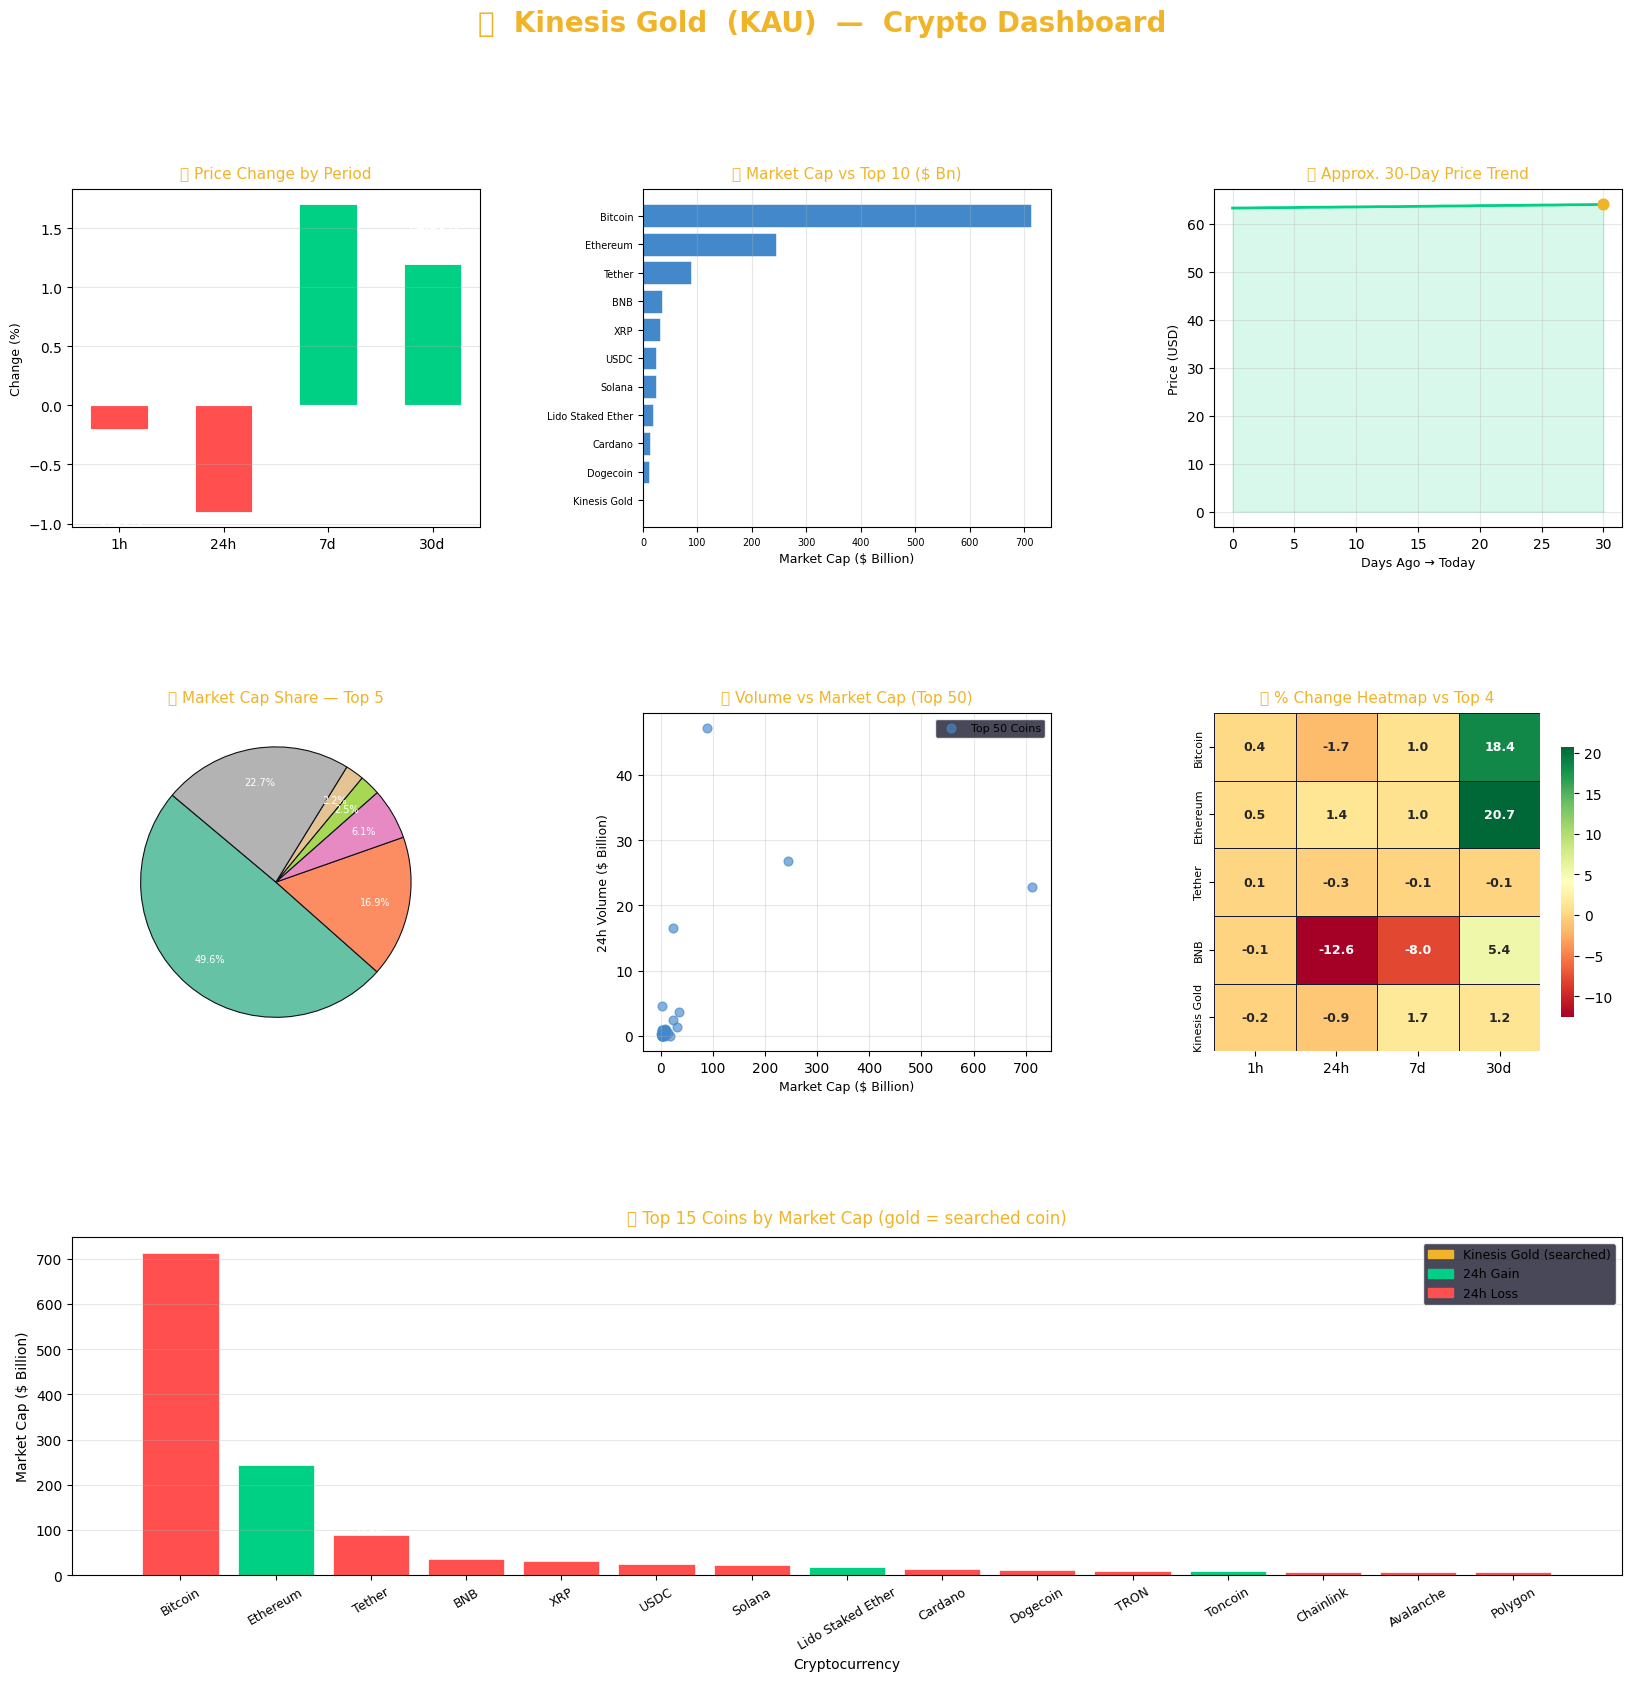

✅ Dashboard saved as "KAU_dashboard.png"


In [27]:

query = input('🔍 Enter cryptocurrency name or symbol: ')
search_crypto(query)